# 01 Dataset Verification

This notebook verifies the raw pilot dataset before any preprocessing is performed.

It checks:

1. metadata structure,
2. referenced image files,
3. basic image properties,
4. a quick visual preview,
5. a saved verification summary.

The notebook intentionally stops after raw dataset verification. Preprocessing, mask generation, restoration, metrics, and reports are handled in later notebooks. Tiny mercy from the chaos gods.

In [19]:
from pathlib import Path
import sys

# Resolve project root whether this notebook is run from project root or notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Source directory exists:", SRC_DIR.exists())

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Source directory exists: True


In [20]:
import matplotlib.pyplot as plt
from PIL import Image

from restoration_eval.paths import RAW_IMAGES_DIR, RAW_METADATA_PATH, OUTPUTS_DIR
from restoration_eval.io_utils import (
    REQUIRED_METADATA_COLUMNS,
    load_metadata,
    validate_required_columns,
    check_image_files,
    collect_image_info,
)

print("Raw images directory:", RAW_IMAGES_DIR)
print("Raw metadata path:", RAW_METADATA_PATH)
print("Images folder exists:", RAW_IMAGES_DIR.exists())
print("Metadata file exists:", RAW_METADATA_PATH.exists())

Raw images directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\raw\images
Raw metadata path: D:\Masters\FH\Thesis\painting-restoration-eval\data\raw\metadata\metadata_pilot.csv
Images folder exists: True
Metadata file exists: True


## 1. Load metadata

In [21]:
metadata = load_metadata(RAW_METADATA_PATH)

print("Metadata shape:", metadata.shape)
display(metadata)

Metadata shape: (3, 11)


,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,filename
0,p001,portrait,Portrait of a Man,Frans Hals,early 1650s,Dutch Golden Age,Oil on canvas,The Met,https://www.metmuseum.org/art/collection/searc...,Public Domain,p001_portrait_hals.jpg
1,p002,landscape,Wall painting: Perseus and Andromeda in landscape,Roman,last decade of the 1st century BCE,Augustan / Roman,Fresco,The Met,https://www.metmuseum.org/art/collection/searc...,Public Domain,p002_landscape_boscotrecase.jpg
2,p003,brushstroke_heavy,Gardanne,Paul Cézanne,[fill from page],Post-Impressionist,Oil on canvas,The Met,https://www.metmuseum.org/art/collection/searc...,Public Domain,p003_cezanne_gardanne.jpg


## 2. Validate metadata columns and referenced image files

In [22]:
missing_columns = validate_required_columns(metadata, REQUIRED_METADATA_COLUMNS)

if missing_columns:
    raise ValueError(f"Missing required metadata columns: {missing_columns}")

print("All required metadata columns are present.")

All required metadata columns are present.


In [23]:
image_file_check = check_image_files(metadata, RAW_IMAGES_DIR)

display(image_file_check)

missing_files = image_file_check.loc[~image_file_check["exists"]]

if not missing_files.empty:
    raise FileNotFoundError(
        "Some image files referenced in metadata are missing. "
        f"Missing rows:\n{missing_files}"
    )

print("All metadata image files exist.")

,painting_id,filename,image_path,exists
0,p001,p001_portrait_hals.jpg,D:\Masters\FH\Thesis\painting-restoration-eval...,True
1,p002,p002_landscape_boscotrecase.jpg,D:\Masters\FH\Thesis\painting-restoration-eval...,True
2,p003,p003_cezanne_gardanne.jpg,D:\Masters\FH\Thesis\painting-restoration-eval...,True


All metadata image files exist.


## 3. Inspect image dimensions and formats

In [24]:
image_info_df = collect_image_info(metadata, RAW_IMAGES_DIR)

display(image_info_df)

,painting_id,filename,width,height,mode,format
0,p001,p001_portrait_hals.jpg,2790,3767,RGB,JPEG
1,p002,p002_landscape_boscotrecase.jpg,2523,3857,RGB,JPEG
2,p003,p003_cezanne_gardanne.jpg,3178,4000,RGB,JPEG


## 4. Visual preview

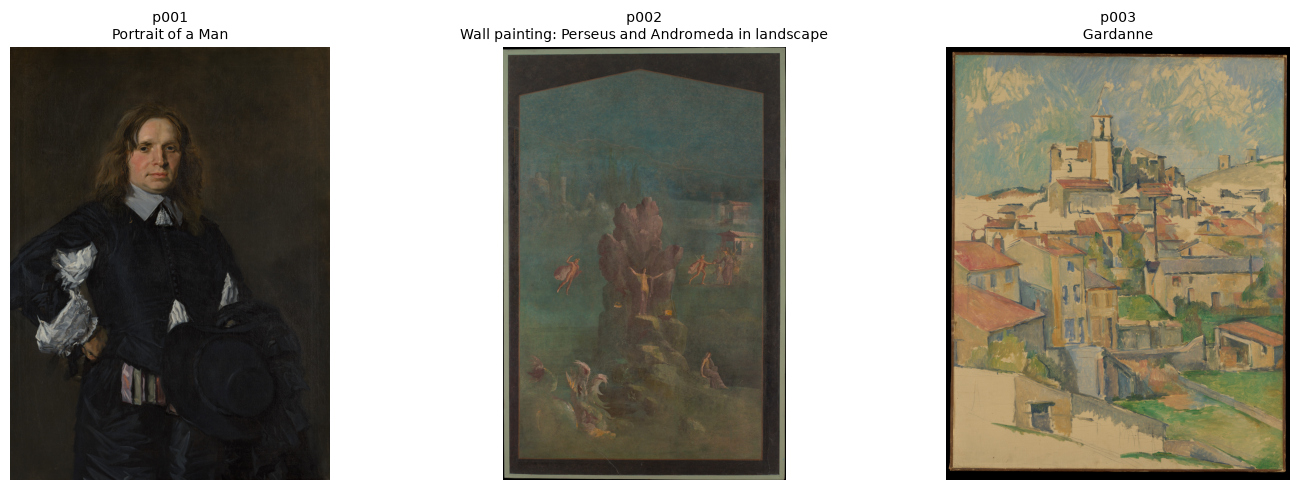

In [25]:
fig, axes = plt.subplots(1, len(metadata), figsize=(15, 5))

if len(metadata) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, metadata.iterrows()):
    image_path = RAW_IMAGES_DIR / row["filename"]

    with Image.open(image_path) as image:
        image = image.convert("RGB")
        ax.imshow(image)
        ax.set_title(f"{row['painting_id']}\n{row['title']}", fontsize=10)
        ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Save verification summary

In [26]:
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

verification_path = OUTPUTS_DIR / "dataset_verification_summary.csv"
image_info_df.to_csv(verification_path, index=False)

print("Saved:", verification_path)

Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\dataset_verification_summary.csv


## Expected result

The notebook is clean if:

- the metadata table has 3 rows,
- all required columns are present,
- all 3 raw image files exist,
- image dimensions/formats display correctly,
- the visual preview shows the 3 paintings,
- `outputs/dataset_verification_summary.csv` is saved.